### Use this notebook to convert your worker1.log to a csv with features needed to build ML model

In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
import sys
import os
sys.path.append(os.path.abspath('../..'))

In [17]:
import pandas as pd 
import numpy as np
import src.scripts.feature_engineering_pipeline as fp
from src.scripts.utils import get_workerlog_all_paths, read_log_as_csv
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [ ]:
# Get paths to all session workerlog files in the runs directory
workerlog_paths = get_workerlog_all_paths("/Users/akshaykishan/PycharmProjects/S4forIluvatar/src/data/runs/")

In [19]:
# Build a main dataframe by iterating through all the workerlog paths and generating features for each log file
main_df = pd.DataFrame()
for i, path in enumerate(workerlog_paths):
    print(f"path {path} started!")
    raw_data = read_log_as_csv(path)
    data = fp.generate_rf_features(raw_data, lags=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 20])
    data['session'] = int(i)
    data['dispatch_policy'] = path.split("/")[-4]
    main_df = pd.concat([main_df, data], ignore_index=True)
    print(f"path {path} completed!")
    print("=="*40)

path /Users/akshaykishan/PycharmProjects/S4forIluvatar/src/data/runs/30_min/4.0/6.0/small-3/0/Landlord/2/4/worker1.log started!
Baseline feature extraction.
Extracting detailed queue state history... this may take a moment.
Enhancing features with local temporal RF lags...
Generating rolling lag features across lags [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 20]...
RF Feature extraction complete!
path /Users/akshaykishan/PycharmProjects/S4forIluvatar/src/data/runs/30_min/4.0/6.0/small-3/0/Landlord/2/4/worker1.log completed!
path /Users/akshaykishan/PycharmProjects/S4forIluvatar/src/data/runs/30_min/4.0/6.0/small-3/0/Landlord/2/12/worker1.log started!
Baseline feature extraction.
Extracting detailed queue state history... this may take a moment.
Enhancing features with local temporal RF lags...
Generating rolling lag features across lags [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 20]...
RF Feature extraction complete!
path /Users/akshaykishan/PycharmProjects/S4forIluvatar/src/data/run

In [20]:
main_df[['gpu_cold_results_sec']].nunique()

gpu_cold_results_sec    12
dtype: int64

In [21]:
main_df['num_running_funcs_filled'].min()

0

In [22]:
main_df['num_running_funcs_filled'].value_counts()

num_running_funcs_filled
1     84553
2     79453
3     77096
0     73047
4     33537
12     5530
5      5146
6      2720
7      1723
8      1055
11     1035
9       839
10      790
13        2
Name: count, dtype: int64

In [23]:
main_df.to_csv("../data/processed/feature_data.csv", index=False)

In [24]:
main_df.groupby('session')['invocation_timestamp'].count().max()

6151

In [25]:
main_df[['dispatch_policy', 'e2etime']].groupby('dispatch_policy').count()

,e2etime
dispatch_policy,
AlwaysGPU,118158
Greedy,50494
Landlord,78534
MICE,54497
NEW_MICE,40743
Speedup,12180
WeightedRandom_0.5,11920


In [26]:
def plot_policy_distributions(df, policy_col='dispatch_policy', target_col='e2etime', use_log=True):
    """
    Creates subplots showing the distribution of latency for each dispatch policy.
    """
    policies = df[policy_col].unique()
    n_policies = len(policies)
    
    # Calculate grid size (e.g., if 3 policies, 1 row 3 cols; if 6, 2 rows 3 cols)
    ncols = 3
    nrows = (n_policies + ncols - 1) // ncols
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharex=True)
    axes = axes.flatten() if n_policies > 1 else [axes]

    for i, policy in enumerate(policies):
        # Filter data
        subset = df[df[policy_col] == policy][target_col]
        
        # Apply log transform for visualization if requested
        plot_data = np.log1p(subset) if use_log else subset
        label = f"Log({target_col})" if use_log else target_col
        
        # Plot histogram
        axes[i].hist(plot_data, bins=30, color='teal', edgecolor='black', alpha=0.7)
        axes[i].set_title(f'Policy: {policy}')
        axes[i].set_xlabel(label)
        axes[i].set_ylabel('Frequency')
        
        # Add mean line for reference
        axes[i].axvline(plot_data.mean(), color='red', linestyle='dashed', linewidth=1, label='Mean')

    # Remove empty subplots if n_policies isn't a perfect multiple of ncols
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(f'Latency Distribution by Dispatch Policy ({"Log-Scaled" if use_log else "Raw"})', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('../reports/charts/policy_distributions.png')
    print("Plot saved as policy_distributions.png")

Plot saved as policy_distributions.png


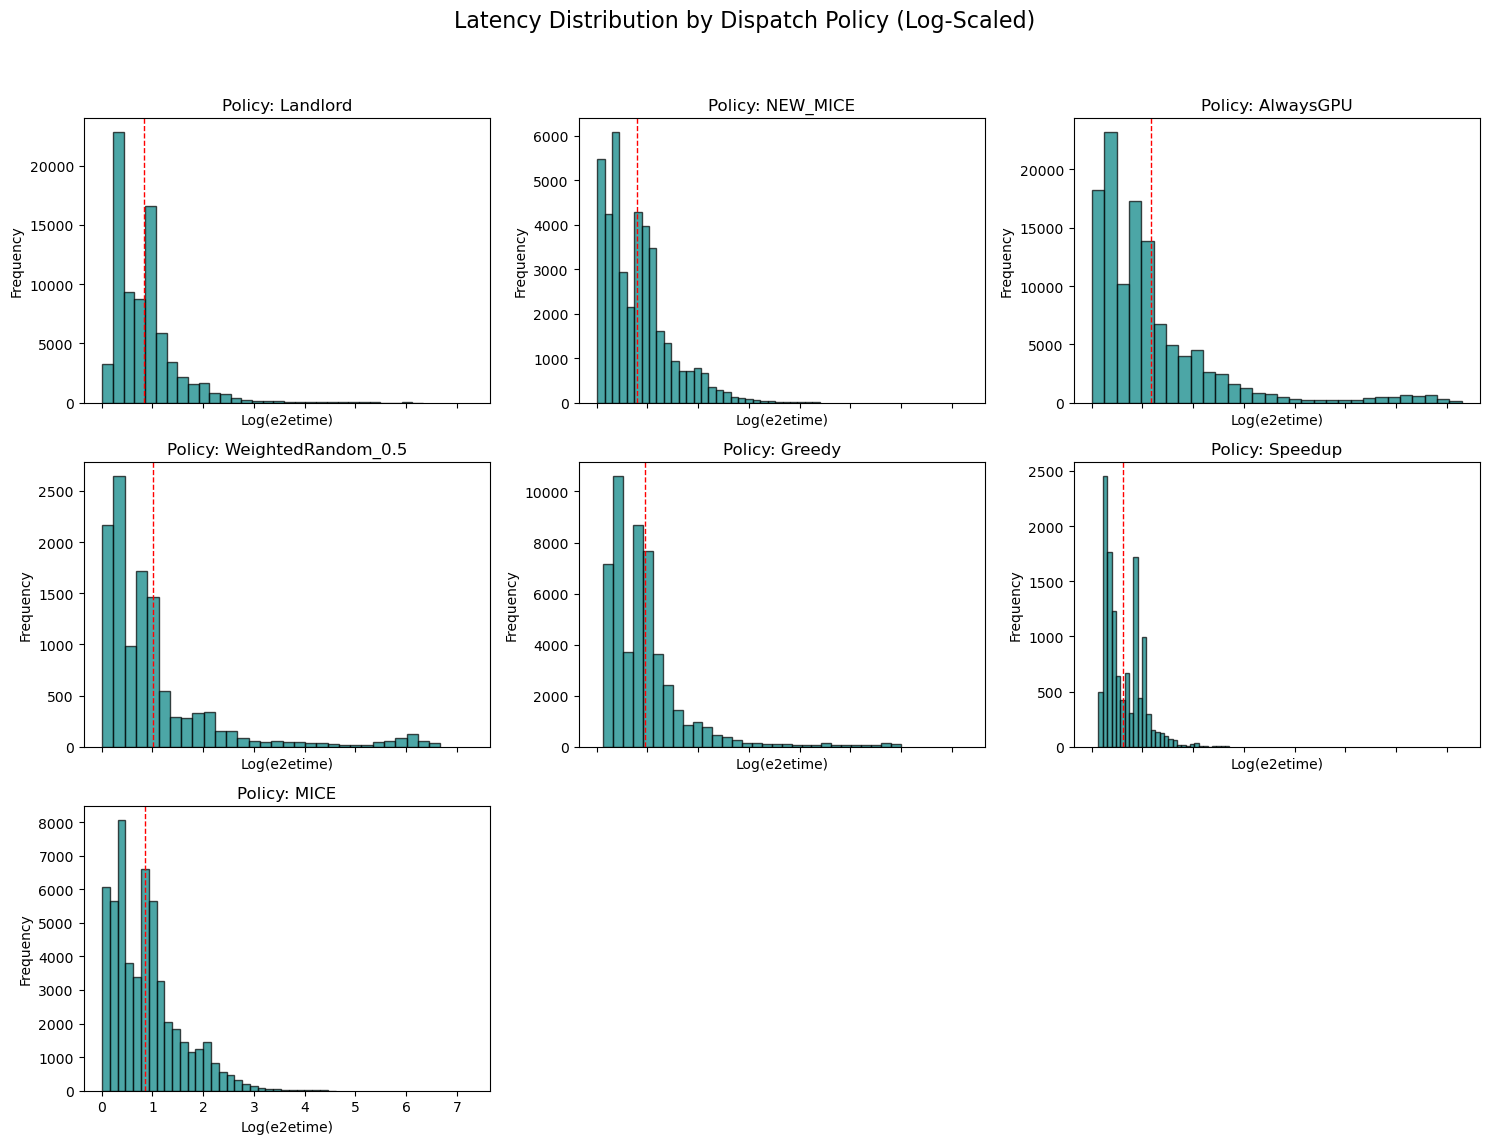

In [27]:
plot_policy_distributions(main_df)

In [28]:
from scipy import stats

def run_distribution_tests(df, policy_col='dispatch_policy', target_col='e2etime'):
    # Prepare groups
    groups = [group[target_col].values for name, group in df.groupby(policy_col)]
    policy_names = df[policy_col].unique()

    print("--- Statistical Test Results ---")
    
    # 1. Kruskal-Wallis (Are they the same globally?)
    stat, p_val = stats.kruskal(*groups)
    print(f"Kruskal-Wallis H-test: p-value = {p_val:.4f}")
    if p_val < 0.05:
        print("Result: Significant difference found. You NEED 'Policy ID' as a model feature.")
    else:
        print("Result: No significant difference. A single simple model is likely fine.")

    # 2. Levene's Test (Is the noise/variance consistent?)
    # Using 'median' is more robust for skewed latency data
    stat_lev, p_lev = stats.levene(*groups, center='median')
    print(f"\nLevene’s Test (Variance): p-value = {p_lev:.4f}")
    if p_lev < 0.05:
        print("Warning: Unequal variances. The model may be biased toward high-latency policies.")

# Usage:
# run_distribution_tests(results_df, 'Dispatch policy', 'e2etime')

In [29]:

run_distribution_tests(main_df)

--- Statistical Test Results ---
Kruskal-Wallis H-test: p-value = 0.0000
Result: Significant difference found. You NEED 'Policy ID' as a model feature.

Levene’s Test (Variance): p-value = 0.0000


In [32]:
main_df[['dispatch_policy', 'e2etime']].groupby('dispatch_policy').mean()

,e2etime
dispatch_policy,
AlwaysGPU,22.409932
Greedy,5.115813
Landlord,2.212516
MICE,2.163610
NEW_MICE,1.851647
Speedup,1.011285
WeightedRandom_0.5,17.447873


<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
/var/folders/0c/stdc2__157d9yghh3sz_pj040000gn/T/ipykernel_96311/2967775229.py:10: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\log(1 + e2etime)$')


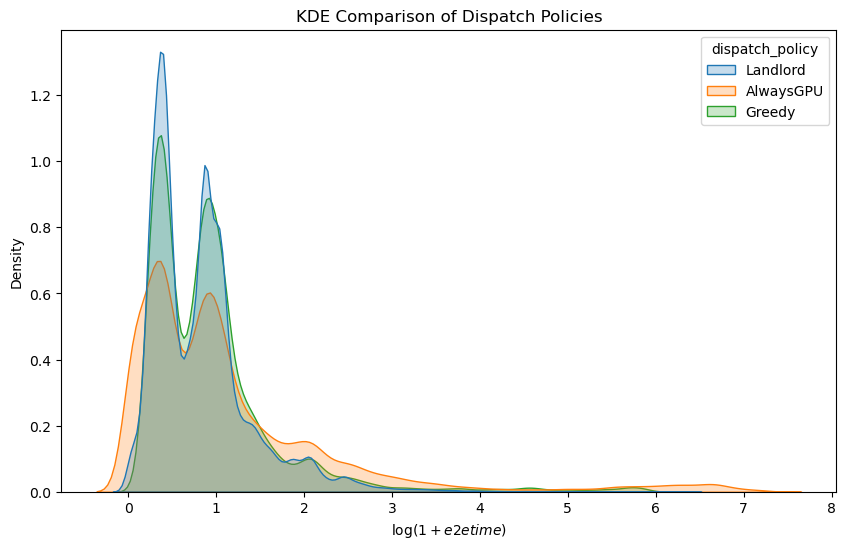

In [33]:
import seaborn as sns

plt.figure(figsize=(10, 6))

# This automatically handles the normalization and draws a smooth line
subset_df = main_df[main_df['dispatch_policy'].isin(['Landlord', 'AlwaysGPU', 'Greedy'])]
sns.kdeplot(data=subset_df, x=np.log1p(subset_df['e2etime']), hue='dispatch_policy', fill=True, common_norm=False)

plt.title('KDE Comparison of Dispatch Policies')
plt.xlabel('$\log(1 + e2etime)$')
plt.ylabel('Density')
plt.show()

In [37]:
bad_sessions = [ 21,  20, 162,  14, 163, 160, 167]

In [39]:
[workerlog_paths[i] for i in bad_sessions]

['/Users/akshaykishan/Akshay/Research/Jan_Run_2/30_min/4.0/6.0/zipf-4*2/0/AlwaysGPU/2/12/worker1.log',
 '/Users/akshaykishan/Akshay/Research/Jan_Run_2/30_min/4.0/6.0/zipf-4*2/0/AlwaysGPU/2/4/worker1.log',
 '/Users/akshaykishan/Akshay/Research/Jan_Run_2/30_min/4.0/6.0/dynamic-4/0/AlwaysGPU/2/12/worker1.log',
 '/Users/akshaykishan/Akshay/Research/Jan_Run_2/30_min/4.0/6.0/small-4/0/WeightedRandom_0.5/2/12/worker1.log',
 '/Users/akshaykishan/Akshay/Research/Jan_Run_2/30_min/4.0/6.0/dynamic-4/0/Greedy/2/12/worker1.log',
 '/Users/akshaykishan/Akshay/Research/Jan_Run_2/30_min/4.0/6.0/dynamic-4/0/Landlord/2/12/worker1.log',
 '/Users/akshaykishan/Akshay/Research/Jan_Run_2/30_min/4.0/6.0/dynamic-3/0/AlwaysGPU/2/12/worker1.log']

In [40]:
ll_test_session = [134, 135, 143, 144, 151, 152, 165, 170]

In [41]:
[workerlog_paths[i] for i in ll_test_session]

['/Users/akshaykishan/Akshay/Research/Jan_Run_2/30_min/4.0/6.0/az-3/0/Landlord/2/4/worker1.log',
 '/Users/akshaykishan/Akshay/Research/Jan_Run_2/30_min/4.0/6.0/az-3/0/Landlord/2/12/worker1.log',
 '/Users/akshaykishan/Akshay/Research/Jan_Run_2/30_min/4.0/6.0/az-4/0/Landlord/2/4/worker1.log',
 '/Users/akshaykishan/Akshay/Research/Jan_Run_2/30_min/4.0/6.0/az-4/0/Landlord/2/12/worker1.log',
 '/Users/akshaykishan/Akshay/Research/Jan_Run_2/30_min/4.0/6.0/az-2/0/Landlord/2/4/worker1.log',
 '/Users/akshaykishan/Akshay/Research/Jan_Run_2/30_min/4.0/6.0/az-2/0/Landlord/2/12/worker1.log',
 '/Users/akshaykishan/Akshay/Research/Jan_Run_2/30_min/4.0/6.0/dynamic-3/0/Landlord/2/12/worker1.log',
 '/Users/akshaykishan/Akshay/Research/Jan_Run_2/30_min/4.0/6.0/dynamic-2/0/Landlord/2/12/worker1.log']